In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33009,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36937,Total threads: 8
Dashboard: http://127.0.0.1:34735/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:34985,


### Load MITgcm Output from Assimilations

In [78]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/tpose6_TAOassim/'

In [48]:
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'

## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+31+28 # nov, dec, jan, feb (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds = xr.concat([ds,ds_new],dim='time')

ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

### Load TAO Data (T and S)

In [107]:
lon_str = '110'

In [68]:
TAO_T_file = '/data/SO3/edavenport/TAO_2012to2016_daily/T_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_T = xr.open_dataset(TAO_T_file)
TAO_S_file = '/data/SO3/edavenport/TAO_2012to2016_daily/S_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_S = xr.open_dataset(TAO_S_file)
dsTAO = xr.merge([dsTAO_T,dsTAO_S])

/tmp/ipykernel_2253094/391557641.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_T,dsTAO_S])


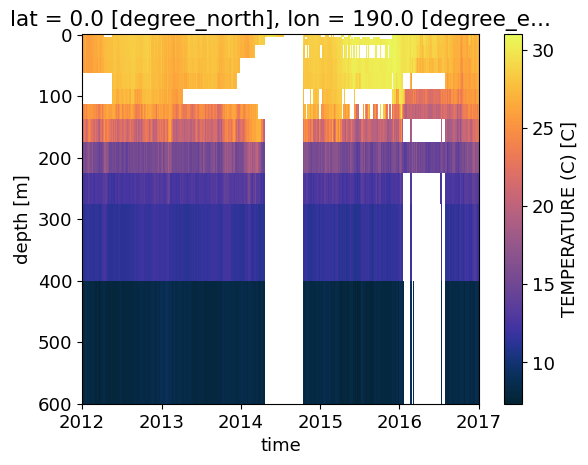

In [69]:
dsTAO.T_20.plot(x='time',cmap=cmo.thermal,yincrease=False)

In [70]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-03-01')) # subset to sep 2012, mar 2013
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XC'})

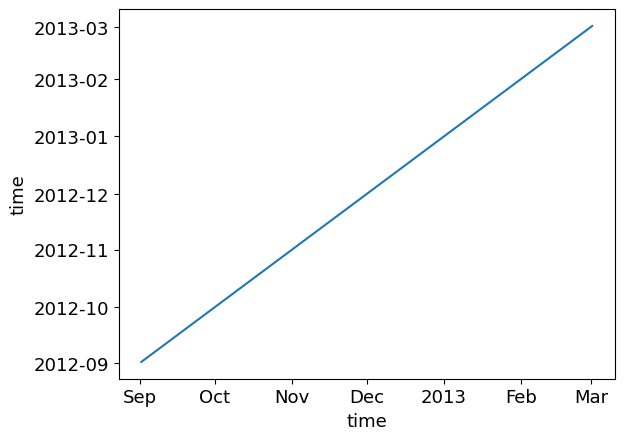

In [71]:
dsTAO.time.plot()

In [72]:
tpose_T = ds.THETA.interp_like(dsTAO.T_20).compute().squeeze()
tpose_S = ds.SALT.interp_like(dsTAO.S_41).compute().squeeze()

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


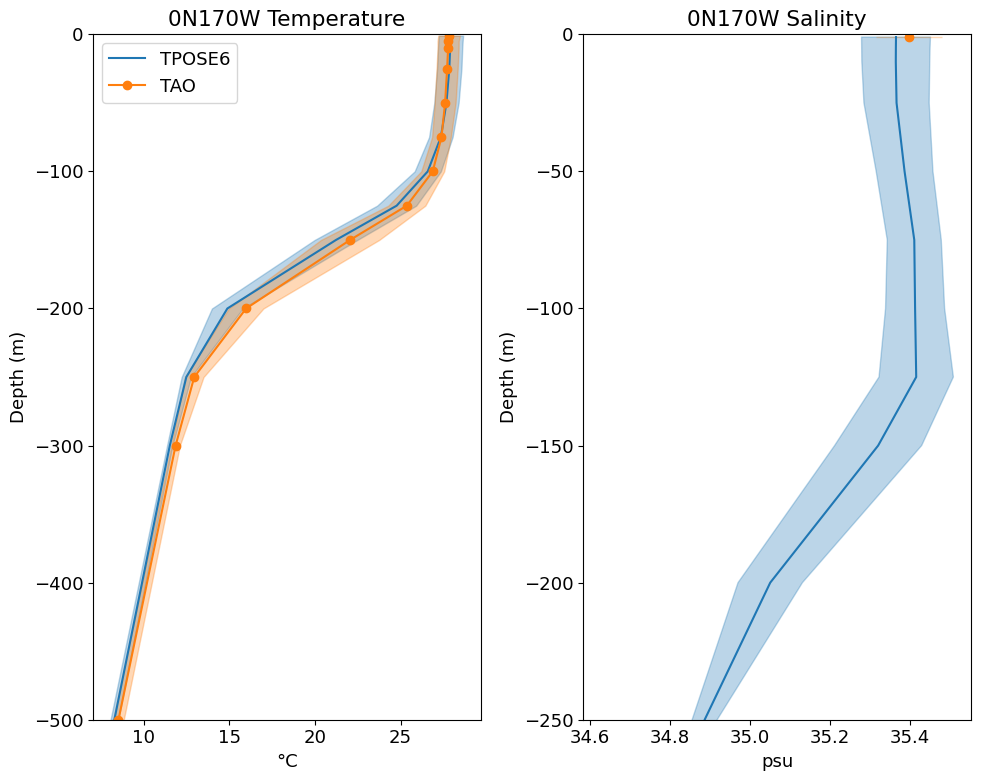

In [73]:
fig,ax = plt.subplots(figsize=(10,8),ncols=2)
tpose_T.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE6')
ax[0].fill_betweenx(tpose_T.Z,tpose_T.mean(dim='time')-tpose_T.std(dim='time'),tpose_T.mean(dim='time')+tpose_T.std(dim='time'),color='C0',alpha=0.3)
TAO_mean = dsTAO.T_20.mean(dim='time').squeeze()
TAO_std = dsTAO.T_20.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[0],y='Z',label='TAO',marker='o')
ax[0].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C1',alpha=0.3)
ax[0].set_title('0N'+ lon_str +'W Temperature')
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('°C')
ax[0].legend()
ax[0].set_ylim(-500,0)

tpose_S.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE6')
ax[1].fill_betweenx(tpose_S.Z,tpose_S.mean(dim='time')-tpose_S.std(dim='time'),tpose_S.mean(dim='time')+tpose_S.std(dim='time'),color='C0',alpha=0.3)
TAO_mean = dsTAO.S_41.mean(dim='time').squeeze()
TAO_std = dsTAO.S_41.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[1],y='Z',label='TAO',marker='o')
ax[1].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C1',alpha=0.3)
ax[1].set_title('0N'+ lon_str +'W Salinity')
ax[1].set_ylabel('Depth (m)')
ax[1].set_xlabel('psu')
ax[1].set_ylim(-250,0)

plt.tight_layout()
fig.savefig(foldername+'TS_' + lon_str + 'W_mean_prof.png')

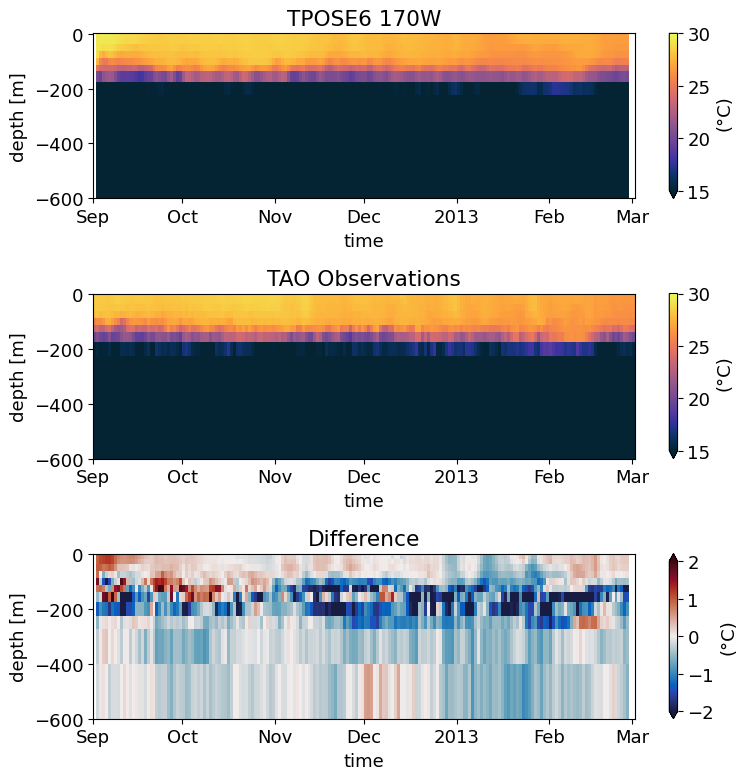

In [74]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,ncols=1)
tpose_T.plot(ax=ax[0],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[0].set_title('TPOSE6 ' + lon_str + 'W')
dsTAO.T_20.plot(ax=ax[1],cmap=cmo.thermal,vmin=15,vmax=30,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[1].set_title('TAO Observations')
(tpose_T - dsTAO.T_20).plot(ax=ax[2],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'(°C)'})
ax[2].set_title('Difference')
plt.tight_layout()
fig.savefig(foldername+'T_' + lon_str + 'W.png')

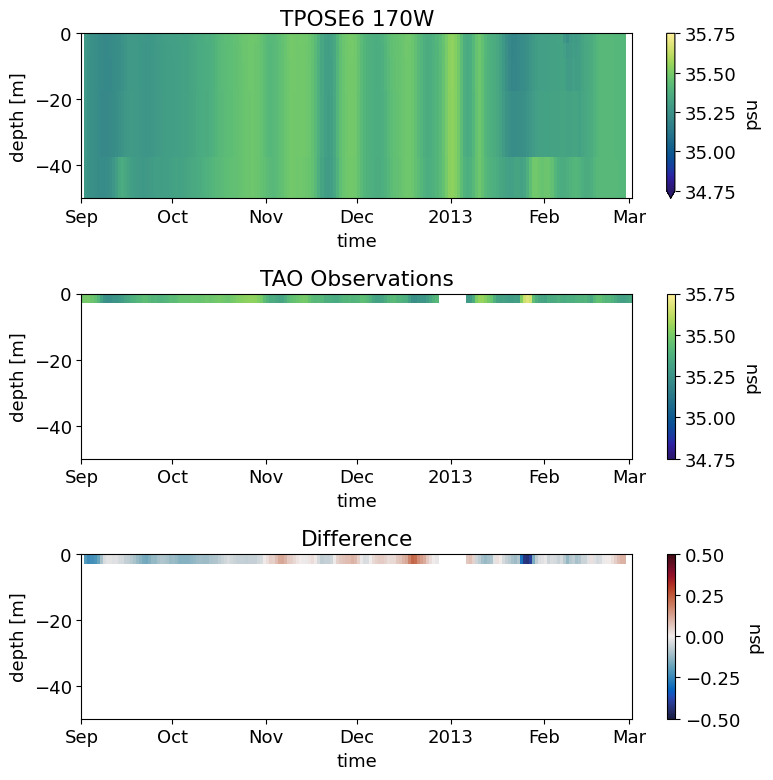

In [75]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,ncols=1)
tpose_S.plot(ax=ax[0],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[0].set_title('TPOSE6 ' + lon_str + 'W')
ax[0].set_ylim(-50,0)
dsTAO.S_41.plot(ax=ax[1],cmap=cmo.haline,vmin=34.75,vmax=35.75,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[1].set_title('TAO Observations')
ax[1].set_ylim(-50,0)
(tpose_S - dsTAO.S_41).plot(ax=ax[2],cmap=cmo.balance,vmin=-0.5,vmax=0.5,x='time',y='Z',cbar_kwargs={'label':'psu'})
ax[2].set_title('Difference')
ax[2].set_ylim(-50,0)
plt.tight_layout()
fig.savefig(foldername+'S_' + lon_str + 'W.png')

### Load TAO U and V

In [108]:
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO = xr.open_dataset(TAO_ADCP_file)

In [109]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-03-01')) # subset to sep 2012, mar 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

In [110]:
dsTAO

<xarray.Dataset> Size: 182kB
Dimensions:  (time: 182, depth: 62, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2012-09-01T12:00:00 ... 2013-03-01T12:...
  * depth    (depth) float32 248B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 4B 250.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 45kB nan nan nan ... nan nan nan
    QU_5205  (time, depth, lat, lon) float32 45kB ...
    v_1206   (time, depth, lat, lon) float32 45kB nan nan nan ... nan nan nan
    QV_5206  (time, depth, lat, lon) float32 45kB ...
Attributes:
    platform_code:                0n110w
    site_code:                    0n110w
    wmo_platform_code:            32323
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                09:59 14-AUG-2024

In [111]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U = ds.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V = ds.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


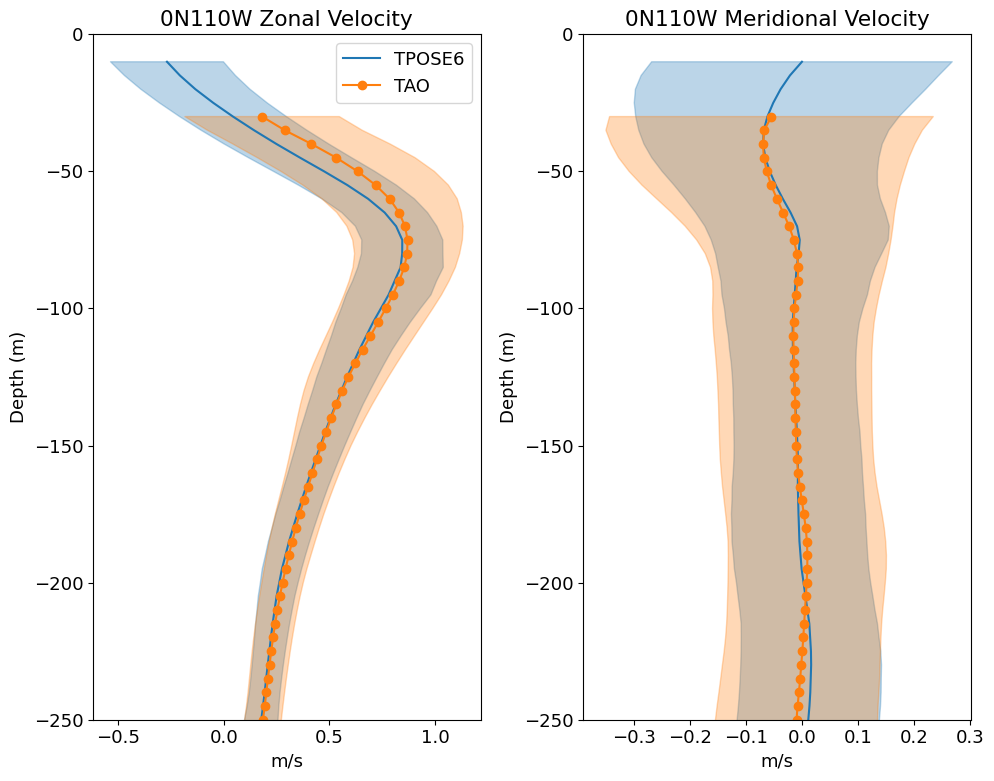

In [112]:
fig,ax = plt.subplots(figsize=(10,8),ncols=2)
ax[0].axvline(0,color='k',linewidth=0.5,label='_nolabel_',linestyle='--')
tpose_U.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE6')
ax[0].fill_betweenx(tpose_U.Z,tpose_U.mean(dim='time')-tpose_U.std(dim='time'),tpose_U.mean(dim='time')+tpose_U.std(dim='time'),color='C0',alpha=0.3)
TAO_mean = dsTAO.u_1205.mean(dim='time').squeeze()
TAO_std = dsTAO.u_1205.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[0],y='Z',label='TAO',marker='o')
ax[0].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C1',alpha=0.3)
ax[0].set_title('0N'+ lon_str +'W Zonal Velocity')
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_ylim(-250,0)

ax[1].axvline(0,color='k',linewidth=0.5,label='_nolabel_',linestyle='--')
tpose_V.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE6')
ax[1].fill_betweenx(tpose_V.Z,tpose_V.mean(dim='time')-tpose_V.std(dim='time'),tpose_V.mean(dim='time')+tpose_V.std(dim='time'),color='C0',alpha=0.3)
TAO_mean = dsTAO.v_1206.mean(dim='time').squeeze()
TAO_std = dsTAO.v_1206.std(dim='time').squeeze()
TAO_mean.plot(ax=ax[1],y='Z',label='TAO',marker='o')
ax[1].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C1',alpha=0.3)
ax[1].set_title('0N'+ lon_str +'W Meridional Velocity')
ax[1].set_ylabel('Depth (m)')
ax[1].set_xlabel('m/s')
ax[1].set_ylim(-250,0)

plt.tight_layout()
fig.savefig(foldername+'UV_' + lon_str + 'W_mean_prof.png')

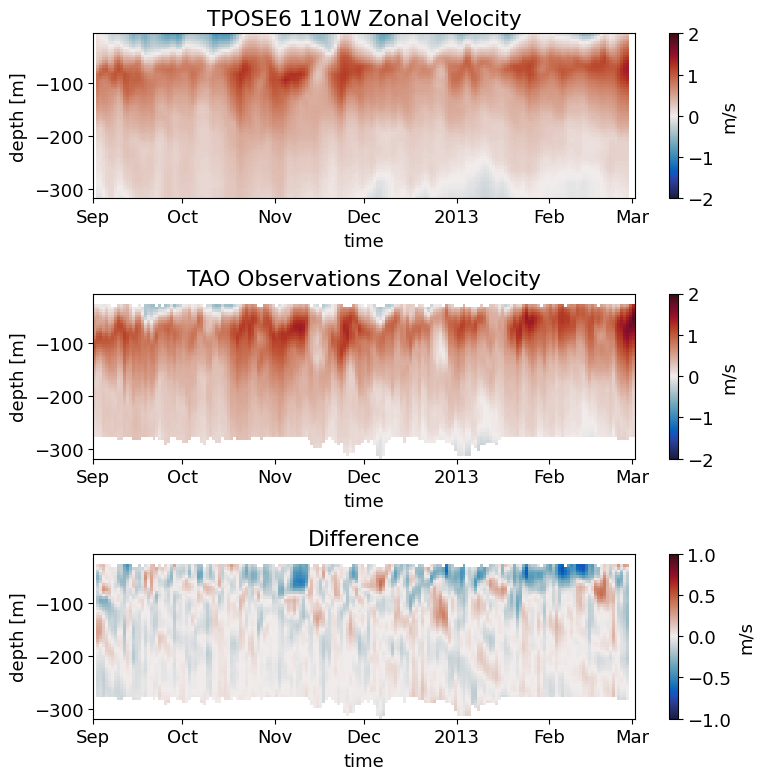

In [113]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,ncols=1)
tpose_U.plot(ax=ax[0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0].set_title('TPOSE6 ' + lon_str + 'W Zonal Velocity')
dsTAO.u_1205.plot(ax=ax[1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1].set_title('TAO Observations Zonal Velocity')
(tpose_U - dsTAO.u_1205).plot(ax=ax[2],cmap=cmo.balance,vmin=-1,vmax=1,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2].set_title('Difference')
plt.tight_layout()
fig.savefig(foldername+'U_' + lon_str + 'W.png')

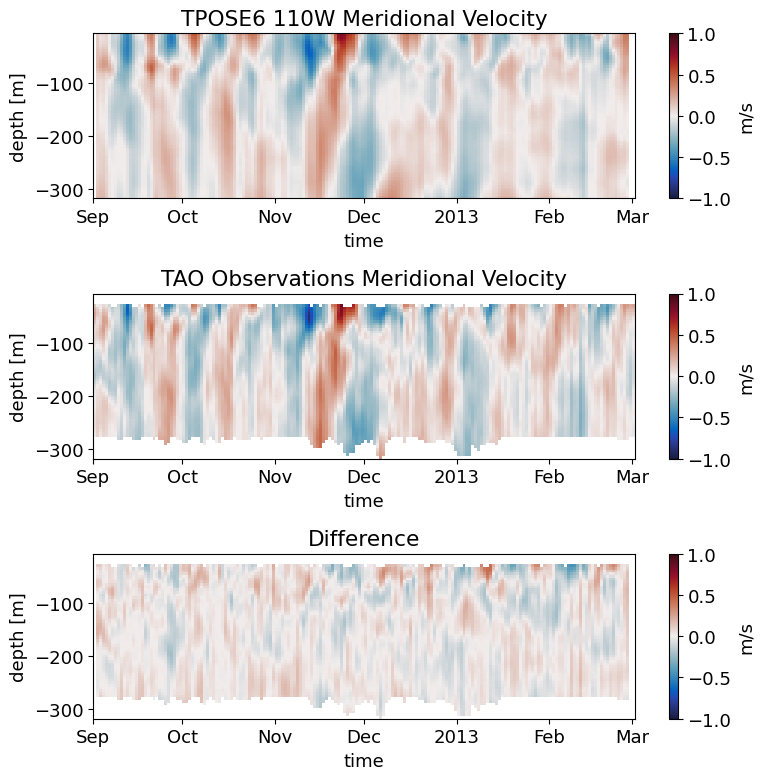

In [114]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,ncols=1)
tpose_V.plot(ax=ax[0],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0].set_title('TPOSE6 ' + lon_str + 'W Meridional Velocity')
dsTAO.v_1206.plot(ax=ax[1],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1].set_title('TAO Observations Meridional Velocity')
(tpose_V - dsTAO.v_1206).plot(ax=ax[2],cmap=cmo.balance,vmin=-1.0,vmax=1.0,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2].set_title('Difference')
plt.tight_layout()
fig.savefig(foldername+'V_' + lon_str + 'W.png')

In [77]:
client.shutdown()
cluster.close()
client.close()